# Day 1 — Market Data Exploration

## Goal

Today I am learning how to retrieve historical stock-market data
and understand the basic OHLCV structure using Python and Pandas.

Stock: AAPL
Data period: 2015–2025

Topics:
- Stock basics
- OHLCV
- Adjusted vs unadjusted prices
- Pandas DataFrame
- Daily returns
- Basic visualization

In [2]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

print("Stock prediction environment is working!")

Stock prediction environment is working!


In [3]:
ticker = yf.Ticker("AAPL")

data = ticker.history(
    start="2015-01-01",
    end="2026-01-01",
    auto_adjust=False
)

data.head()

,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits
Date,,,,,,,,
2015-01-02 00:00:00-05:00,27.847500,27.860001,26.837500,27.332500,24.171759,212818400,0.0,0.0
2015-01-05 00:00:00-05:00,27.072500,27.162500,26.352501,26.562500,23.490801,257142000,0.0,0.0
2015-01-06 00:00:00-05:00,26.635000,26.857500,26.157499,26.565001,23.493013,263188400,0.0,0.0
2015-01-07 00:00:00-05:00,26.799999,27.049999,26.674999,26.937500,23.822432,160423600,0.0,0.0
2015-01-08 00:00:00-05:00,27.307501,28.037500,27.174999,27.972500,24.737749,237458000,0.0,0.0


In [10]:
data.shape

(2766, 8)

In [11]:
data.info

<bound method DataFrame.info of                                  Open        High         Low       Close  \
Date                                                                        
2015-01-02 00:00:00-05:00   27.847500   27.860001   26.837500   27.332500   
2015-01-05 00:00:00-05:00   27.072500   27.162500   26.352501   26.562500   
2015-01-06 00:00:00-05:00   26.635000   26.857500   26.157499   26.565001   
2015-01-07 00:00:00-05:00   26.799999   27.049999   26.674999   26.937500   
2015-01-08 00:00:00-05:00   27.307501   28.037500   27.174999   27.972500   
...                               ...         ...         ...         ...   
2025-12-24 00:00:00-05:00  272.339996  275.429993  272.200012  273.809998   
2025-12-26 00:00:00-05:00  274.160004  275.369995  272.859985  273.399994   
2025-12-29 00:00:00-05:00  272.690002  274.359985  272.350006  273.760010   
2025-12-30 00:00:00-05:00  272.809998  274.079987  272.279999  273.079987   
2025-12-31 00:00:00-05:00  273.059998  273.6

In [12]:
data[["Open", "High", "Low", "Close", "Volume"]].head()

,Open,High,Low,Close,Volume
Date,,,,,
2015-01-02 00:00:00-05:00,27.847500,27.860001,26.837500,27.332500,212818400
2015-01-05 00:00:00-05:00,27.072500,27.162500,26.352501,26.562500,257142000
2015-01-06 00:00:00-05:00,26.635000,26.857500,26.157499,26.565001,263188400
2015-01-07 00:00:00-05:00,26.799999,27.049999,26.674999,26.937500,160423600
2015-01-08 00:00:00-05:00,27.307501,28.037500,27.174999,27.972500,237458000


In [17]:
data["Close"]

Date
2015-01-02 00:00:00-05:00     27.332500
2015-01-05 00:00:00-05:00     26.562500
2015-01-06 00:00:00-05:00     26.565001
2015-01-07 00:00:00-05:00     26.937500
2015-01-08 00:00:00-05:00     27.972500
                                ...    
2025-12-24 00:00:00-05:00    273.809998
2025-12-26 00:00:00-05:00    273.399994
2025-12-29 00:00:00-05:00    273.760010
2025-12-30 00:00:00-05:00    273.079987
2025-12-31 00:00:00-05:00    271.859985
Name: Close, Length: 2766, dtype: float64

In [18]:
data["daily_return"] = data["Adj Close"].pct_change()

In [19]:
data[["Adj Close", "daily_return"]].head(10)

,Adj Close,daily_return
Date,,
2015-01-02 00:00:00-05:00,24.171759,NaN
2015-01-05 00:00:00-05:00,23.490801,-0.028172
2015-01-06 00:00:00-05:00,23.493013,0.000094
2015-01-07 00:00:00-05:00,23.822432,0.014022
2015-01-08 00:00:00-05:00,24.737749,0.038423
2015-01-09 00:00:00-05:00,24.764282,0.001073
2015-01-12 00:00:00-05:00,24.154070,-0.024641
2015-01-13 00:00:00-05:00,24.368528,0.008879
2015-01-14 00:00:00-05:00,24.275677,-0.003810


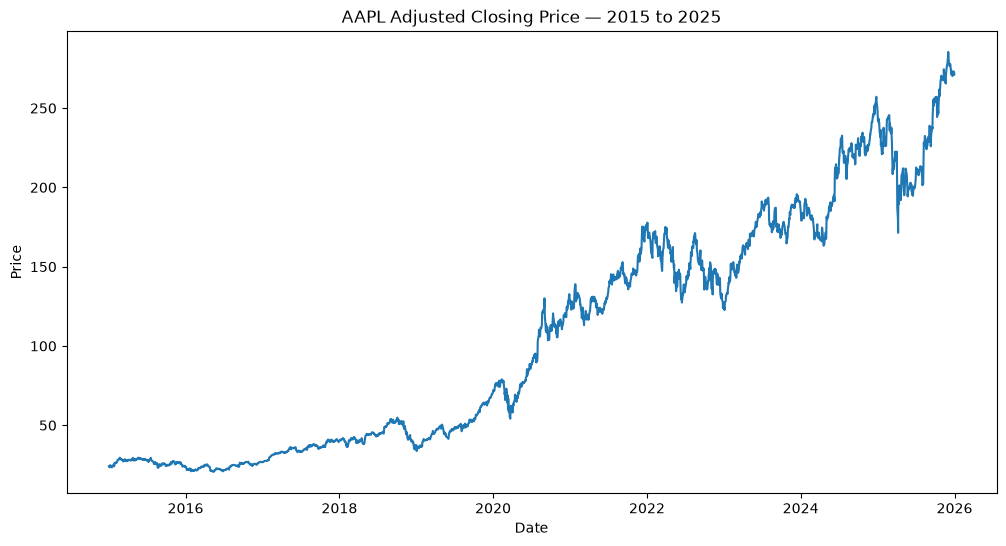

In [24]:
plt.figure(figsize=(12, 6))

plt.plot(data.index, data["Adj Close"])

plt.title("AAPL Adjusted Closing Price — 2015 to 2025")
plt.xlabel("Date")
plt.ylabel("Price")

plt.show()

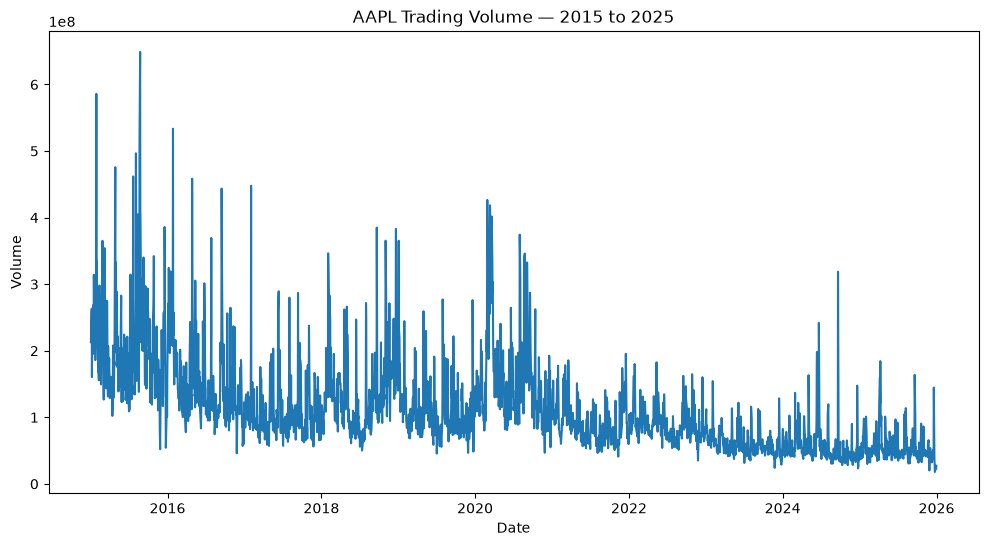

In [25]:
plt.figure(figsize=(12, 6))

plt.plot(data.index, data["Volume"])

plt.title("AAPL Trading Volume — 2015 to 2025")
plt.xlabel("Date")
plt.ylabel("Volume")

plt.show()

In [26]:
data["daily_return"].mean()

np.float64(0.0010394901985760268)

In [29]:
data["daily_return"].std()


np.float64(0.01817115233224027)

In [30]:
data["daily_return"].max()

np.float64(0.1532885035937399)